6a-Program

In [ ]:
import nltk, re, pprint
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns
import pprint, time
import random
from sklearn.model_selection import train_test_split
from nltk.tokenize import word_tokenize

nltk.download('treebank') # Download the 'treebank' corpus
nltk.download('universal_tagset') # Download the 'universal_tagset' resource

# reading the Treebank tagged sentences
wsj = list(nltk.corpus.treebank.tagged_sents(tagset='universal'))


[nltk_data] Downloading package treebank to /root/nltk_data...
[nltk_data]   Unzipping corpora/treebank.zip.
[nltk_data] Downloading package universal_tagset to /root/nltk_data...
[nltk_data]   Unzipping taggers/universal_tagset.zip.


In [ ]:
# first few tagged sentences
print(wsj[:40])

[[('Pierre', 'NOUN'), ('Vinken', 'NOUN'), (',', '.'), ('61', 'NUM'), ('years', 'NOUN'), ('old', 'ADJ'), (',', '.'), ('will', 'VERB'), ('join', 'VERB'), ('the', 'DET'), ('board', 'NOUN'), ('as', 'ADP'), ('a', 'DET'), ('nonexecutive', 'ADJ'), ('director', 'NOUN'), ('Nov.', 'NOUN'), ('29', 'NUM'), ('.', '.')], [('Mr.', 'NOUN'), ('Vinken', 'NOUN'), ('is', 'VERB'), ('chairman', 'NOUN'), ('of', 'ADP'), ('Elsevier', 'NOUN'), ('N.V.', 'NOUN'), (',', '.'), ('the', 'DET'), ('Dutch', 'NOUN'), ('publishing', 'VERB'), ('group', 'NOUN'), ('.', '.')], [('Rudolph', 'NOUN'), ('Agnew', 'NOUN'), (',', '.'), ('55', 'NUM'), ('years', 'NOUN'), ('old', 'ADJ'), ('and', 'CONJ'), ('former', 'ADJ'), ('chairman', 'NOUN'), ('of', 'ADP'), ('Consolidated', 'NOUN'), ('Gold', 'NOUN'), ('Fields', 'NOUN'), ('PLC', 'NOUN'), (',', '.'), ('was', 'VERB'), ('named', 'VERB'), ('*-1', 'X'), ('a', 'DET'), ('nonexecutive', 'ADJ'), ('director', 'NOUN'), ('of', 'ADP'), ('this', 'DET'), ('British', 'ADJ'), ('industrial', 'ADJ'), ('

In [ ]:
# Splitting into train and test
random.seed (1234)
train_set, test_set = train_test_split(wsj,test_size=0.05)
print(len(train_set))
print(len(test_set))
print(train_set[:40])


3718
196
[[('Only', 'ADV'), ('19', 'NUM'), ('%', 'NOUN'), ('of', 'ADP'), ('the', 'DET'), ('purchasing', 'VERB'), ('managers', 'NOUN'), ('reported', 'VERB'), ('better', 'ADJ'), ('export', 'NOUN'), ('orders', 'NOUN'), ('in', 'ADP'), ('October', 'NOUN'), (',', '.'), ('down', 'ADV'), ('from', 'ADP'), ('27', 'NUM'), ('%', 'NOUN'), ('in', 'ADP'), ('September', 'NOUN'), ('.', '.')], [('A', 'DET'), ('trend', 'NOUN'), ('that', 'DET'), ('*T*-72', 'X'), ('started', 'VERB'), ('with', 'ADP'), ('the', 'DET'), ('first', 'ADJ'), ('stirrings', 'NOUN'), ('of', 'ADP'), ('politics', 'NOUN'), (',', '.'), ('accelerated', 'VERB'), ('with', 'ADP'), ('the', 'DET'), ('dawn', 'NOUN'), ('of', 'ADP'), ('the', 'DET'), ('television', 'NOUN'), ('age', 'NOUN'), ('and', 'CONJ'), ('became', 'VERB'), ('a', 'DET'), ('sometimes-tawdry', 'ADJ'), ('art', 'NOUN'), ('form', 'NOUN'), ('in', 'ADP'), ('1988', 'NUM'), (',', '.'), ('has', 'VERB'), ('reached', 'VERB'), ('an', 'DET'), ('entirely', 'ADV'), ('new', 'ADJ'), ('stage', 'N

In [ ]:
# Getting list of tagged words
train_tagged_words = [tup for sent in train_set for tup in sent]
len(train_tagged_words)

95598

In [ ]:
# tokens
tokens = [pair[0] for pair in train_tagged_words]
tokens [:10]

['Only',
 '19',
 '%',
 'of',
 'the',
 'purchasing',
 'managers',
 'reported',
 'better',
 'export']

In [ ]:
# vocabulary
V = set(tokens)
print(len(V))

12080


In [ ]:
# number of tags
T = set([pair[1] for pair in train_tagged_words])
len(T)


12

In [ ]:
print(T)

{'ADV', 'DET', 'NUM', 'X', 'VERB', 'NOUN', 'PRT', 'PRON', 'CONJ', 'ADP', 'ADJ', '.'}


HMM(Hidden Markov Model) - POS Tagging Algorithm
Emission Probabilities

In [ ]:
# computing P(w/t) and storing in T x V matrix
t = len(T)
v = len(V)
w_given_t = np.zeros((t, v))
# compute word given tag: Emission Probability
def word_given_tag(word, tag, train_bag = train_tagged_words):
    tag_list = [pair for pair in train_bag if pair[1]==tag]
    count_tag = len(tag_list)
    w_given_tag_list = [pair[0] for pair in tag_list if pair[0]==word]
    count_w_given_tag = len(w_given_tag_list)
    return (count_w_given_tag, count_tag)
# examples
# large
print("\n", "large")
print(word_given_tag('large', 'ADJ'))
print(word_given_tag('large', 'VERB'))
print(word_given_tag('large', 'NOUN'), "\n")
# will
print("\n", "will")
print(word_given_tag('will', 'MD'))
print(word_given_tag('will', 'NOUN'))
print(word_given_tag('will', 'VERB'))
# book
print("\n", "book")
print(word_given_tag('book', 'NOUN'))
print(word_given_tag('book', 'VERB'))


 large
(26, 6105)
(0, 12870)
(0, 27469) 


 will
(0, 0)
(1, 27469)
(262, 12870)

 book
(6, 27469)
(1, 12870)


In [ ]:
word_given_tag('Twitter', 'NOUN')

(0, 27469)

Transisition Probabilities

In [ ]:
def t2_given_t1(t2, t1, train_bag = train_tagged_words):
    tags = [pair[1] for pair in train_bag]
    count_t1 = len([t for t in tags if t==t1])
    count_t2_t1 = 0
    for index in range(len(tags)-1):
        if tags[index]==t1 and tags[index+1] == t2:
            count_t2_t1 += 1
    return (count_t2_t1, count_t1)

In [ ]:
# examples
print(t2_given_t1(t2='NOUN', t1='ADJ'))
print(t2_given_t1('ADJ', 'NOUN'))
print(t2_given_t1('NOUN', 'DET'))
print(t2_given_t1('NOUN', 'VERB'))
print(t2_given_t1(',', 'NOUN'))
print(t2_given_t1('PRT', 'PRT'))
print(t2_given_t1('VERB', 'NOUN'))

(4285, 6105)
(335, 27469)
(5279, 8280)
(1431, 12870)
(0, 27469)
(6, 3042)
(4042, 27469)


In [ ]:
#Please note P(tag|start) is same as P(tag|'.')
print(t2_given_t1('DET', '.'))
print(t2_given_t1('VERB', '.'))
print(t2_given_t1('NOUN', '.'))
print(t2_given_t1('NOUN', '.'))




(1939, 11108)
(989, 11108)
(2465, 11108)
(2465, 11108)


In [ ]:
t2_given_t1('VERB', 'DET')

(328, 8280)

In [ ]:
# creating txt transition matrix of tags
# each column is t2, each row is t1
# thus M(i, j) represents P(tj given ti)
tags_matrix = np.zeros((len(T), len(T)), dtype='float32')
for i, t1 in enumerate(list(T)):
    for j, t2 in enumerate(list(T)):
        tags_matrix[i, j] = t2_given_t1(t2, t1)[0]/t2_given_t1(t2, t1)[1]
tags_matrix

array([[7.67441839e-02, 6.77740872e-02, 3.08970101e-02, 2.35880390e-02,
        3.48172754e-01, 3.22259143e-02, 1.39534883e-02, 1.52823916e-02,
        6.97674416e-03, 1.15946844e-01, 1.29235879e-01, 1.39202654e-01],
       [1.24396132e-02, 5.55555569e-03, 2.22222228e-02, 4.60144915e-02,
        3.96135263e-02, 6.37560368e-01, 2.41545888e-04, 3.50241549e-03,
        4.83091775e-04, 9.05797072e-03, 2.05314010e-01, 1.79951694e-02],
       [2.98151467e-03, 3.27966618e-03, 1.85748354e-01, 2.08109722e-01,
        1.78890880e-02, 3.55396539e-01, 2.71317828e-02, 1.49075733e-03,
        1.37149673e-02, 3.33929621e-02, 3.30948122e-02, 1.17769830e-01],
       [2.57311817e-02, 5.48186041e-02, 2.71695689e-03, 7.49560520e-02,
        2.06169084e-01, 6.16909079e-02, 1.82835221e-01, 5.54578863e-02,
        1.03883650e-02, 1.46875501e-01, 1.69410259e-02, 1.61419213e-01],
       [8.16627815e-02, 1.34343430e-01, 2.24553216e-02, 2.17715621e-01,
        1.68142974e-01, 1.11188814e-01, 3.13131325e-02, 3.59

In [ ]:
# convert the matrix to a df for better readability
tags_df = pd.DataFrame(tags_matrix, columns = list(T), index=list(T))
tags_df


,ADV,DET,NUM,X,VERB,NOUN,PRT,PRON,CONJ,ADP,ADJ,.
ADV,0.076744,0.067774,0.030897,0.023588,0.348173,0.032226,0.013953,0.015282,0.006977,0.115947,0.129236,0.139203
DET,0.012440,0.005556,0.022222,0.046014,0.039614,0.637560,0.000242,0.003502,0.000483,0.009058,0.205314,0.017995
NUM,0.002982,0.003280,0.185748,0.208110,0.017889,0.355397,0.027132,0.001491,0.013715,0.033393,0.033095,0.117770
X,0.025731,0.054819,0.002717,0.074956,0.206169,0.061691,0.182835,0.055458,0.010388,0.146876,0.016941,0.161419
VERB,0.081663,0.134343,0.022455,0.217716,0.168143,0.111189,0.031313,0.035975,0.005439,0.090909,0.065967,0.034887
NOUN,0.017183,0.013288,0.009611,0.028541,0.147148,0.264407,0.043940,0.004842,0.042411,0.176672,0.012196,0.239761
PRT,0.010191,0.100263,0.057199,0.013478,0.397436,0.248192,0.001972,0.018080,0.001972,0.021368,0.086456,0.043393
PRON,0.034257,0.010008,0.007313,0.094303,0.481139,0.209777,0.012317,0.007313,0.005389,0.022325,0.075443,0.040416
CONJ,0.054520,0.118360,0.041473,0.006990,0.157036,0.350419,0.004194,0.060112,0.000466,0.053588,0.118826,0.034017
ADP,0.013890,0.323646,0.062400,0.034726,0.008548,0.322577,0.001282,0.069345,0.000855,0.016668,0.106528,0.039534


In [ ]:
tags_df.loc['.', :]

,.
ADV,0.052665
DET,0.174559
NUM,0.080753
X,0.027278
VERB,0.089035
NOUN,0.221912
PRT,0.002431
PRON,0.064818
CONJ,0.057976
ADP,0.090925


Heat Map of Tags Matrix

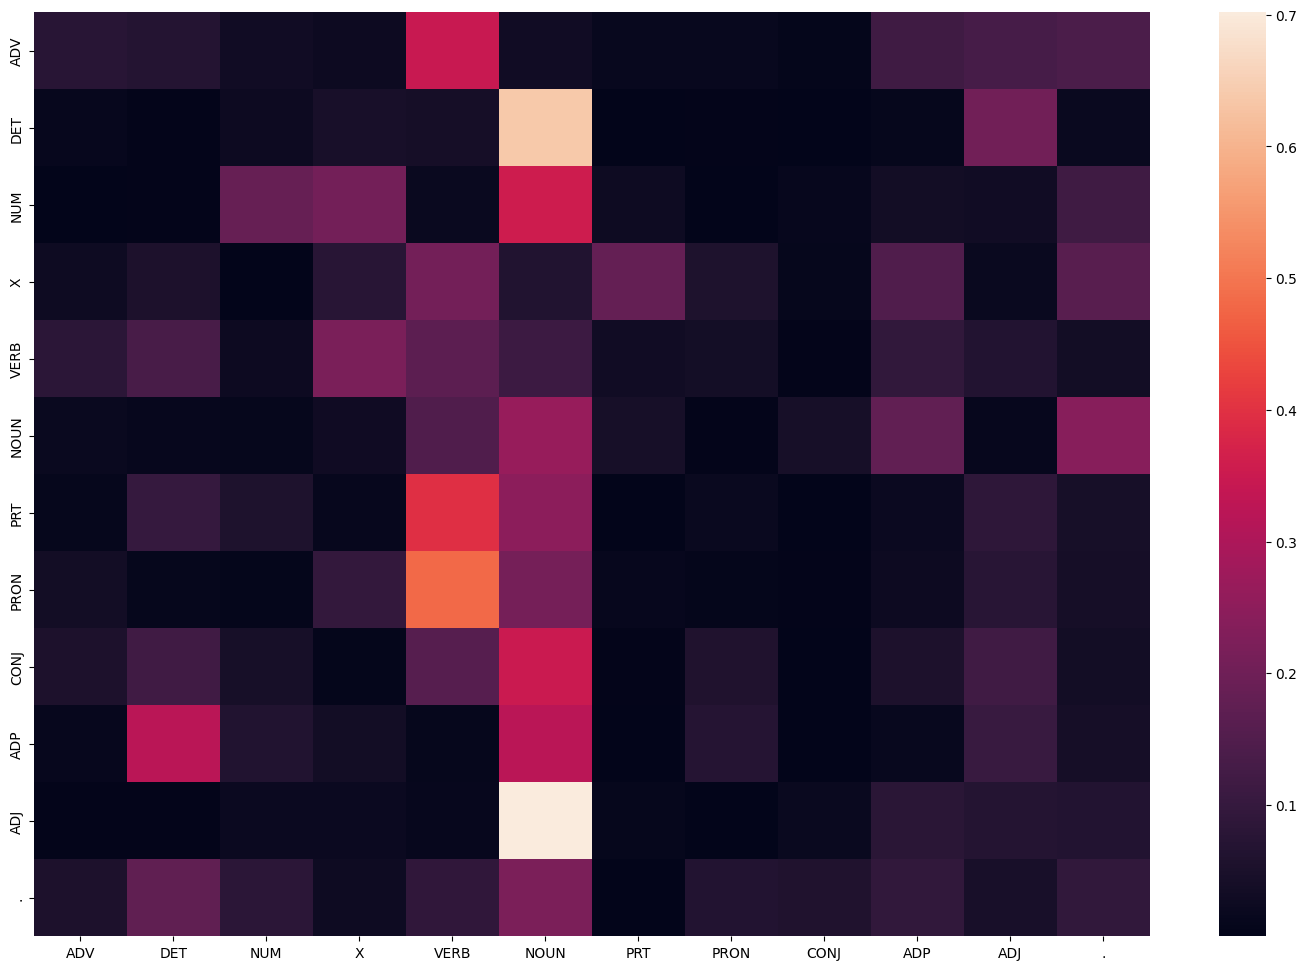

In [ ]:
# T(i, j) means P(tag j given tag i)
plt.figure(figsize=(18, 12))
sns.heatmap(tags_df)
plt.show()

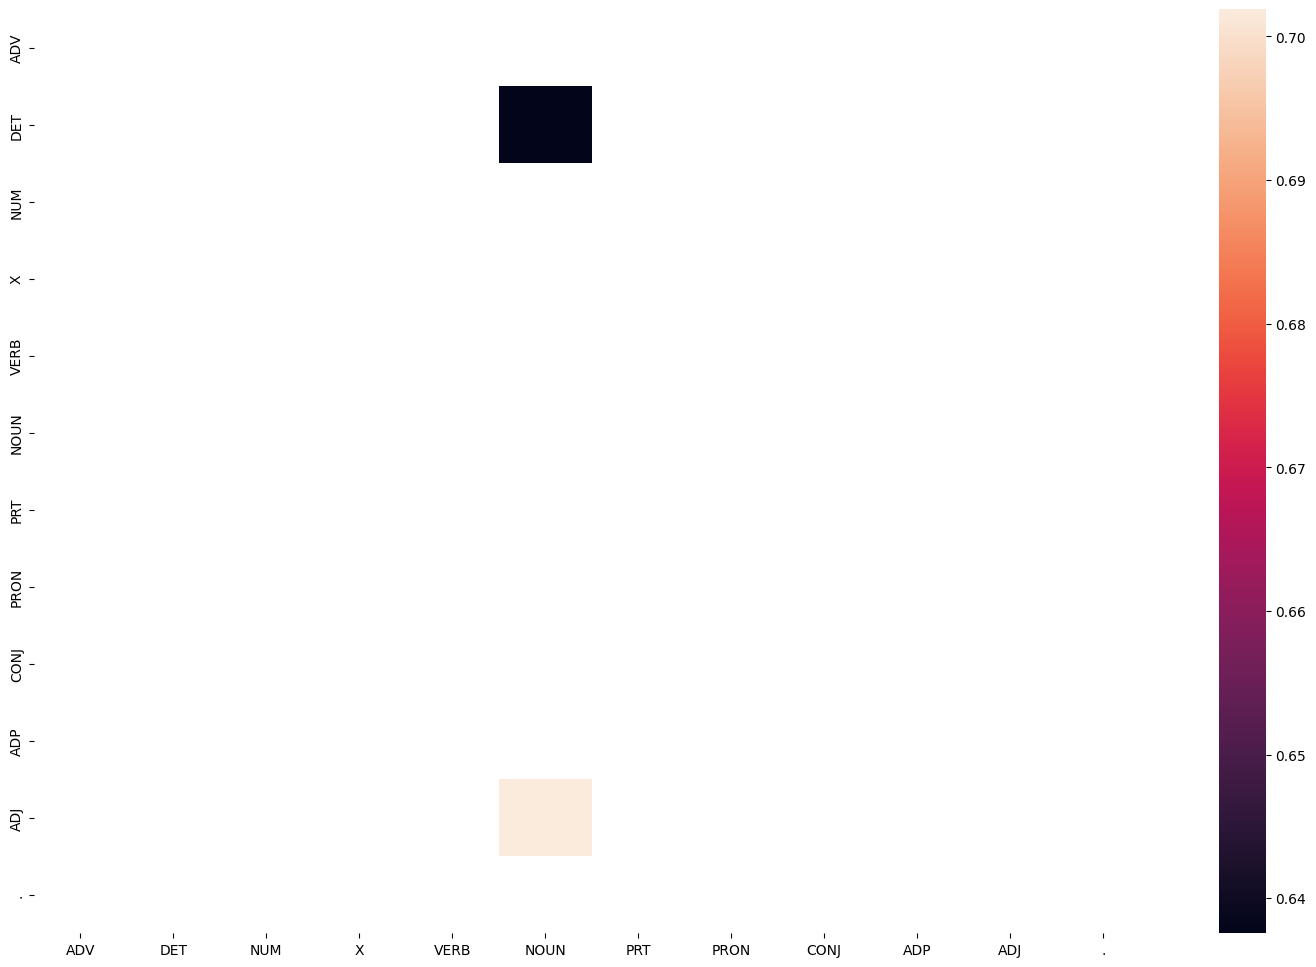

In [ ]:
# frequent tags
# filter the df to get P(t2, t1) > 0.5
tags_frequent = tags_df[tags_df>0.5]
plt.figure(figsize=(18, 12))
sns.heatmap(tags_frequent)
plt.show()

 Viterbi Algorithm

Vanilla Viterbi

In [ ]:
def Viterbi_vanilla(words, train_bag = train_tagged_words):
    state = []
    T = list(set([pair[1] for pair in train_bag]))
    for key, word in enumerate(words):
        #initialise list of probability column for a given observation
        p = []
        for tag in T:
            if key == 0:
                transition_p = tags_df.loc['.', tag]
            else:
                transition_p = tags_df.loc[state[-1], tag]
            # compute emission and state probabilities
            emission_p = word_given_tag(words [key], tag)[0]/word_given_tag(words[key], tag) [1]
            state_probability = emission_p * transition_p
            p.append(state_probability)
        #print('word is {} and list is {}'.format(word,p))
        pmax = max(p)
        # getting state for which probability is maximum
        state_max = T[p.index(pmax)]
        state.append(state_max)
    return list(zip(words, state))

Vanilla Laplace smoothened

In [ ]:
def Viterbi_smoothed(words, train_bag = train_tagged_words):
    state = []
    T = list(set([pair[1] for pair in train_bag]))
    for key, word in enumerate(words):
        #initialise list of probability column for a given observation
        p = []
        for tag in T:
            if key == 0:
                transition_p = tags_df.loc['.', tag]
            else:
                transition_p = tags_df.loc[state[-1], tag]
            # compute emission and state probabilities
            emission_p = 0.000001+word_given_tag(words [key], tag)[0]/word_given_tag(words [key], tag) [1]+0.000001*len(T)
            state_probability = emission_p * transition_p
            p.append(state_probability)
        #print('word is {} and list is {}'.format(word,p))
        pmax = max(p)
        # getting state for which probability is maximum
        state_max = T[p.index(pmax)]
        state.append(state_max)
    return list(zip(words, state))

Viterbi with RegExp for unknown words

In [ ]:
def find_state(word):
    #punc=['"',"'",',','.','(',')','?','[',']',':',';']
    # xc=['*'] # This was likely intended for the X tag logic below, but not needed as a separate list.
    if re.search(r'.*(ing|ed|es|ould)$', word.lower()):
        return 'VERB'
    elif re.search(r'to$', str(word).lower()):
        return 'PRT'
    elif re.search(r'^-?[0-9]+(\.[0-9]+)?$', str(word).lower()):
        return 'NUM'
    elif '*' in word:
        return 'X'
    elif re.search(r'.*\'s$', word.lower()):
        return 'NOUN'
    elif re.search(r'.*ness$', word.lower()):
        return 'NOUN'
    elif re.search(r'(The|the|A|a|An|an)$', word):
        return 'DET'
    elif re.search(r'.*able$', word.lower()):
        return 'ADJ'
    elif re.search(r'.*ly$', word.lower()):
        return 'ADV'
    # NLP_LAB6.ipynb - Colaboratory
    elif re.search(r'(He|he|She|she|It|it|I|me|Me|You|you|His|his|Her|her|Its|its|my|Your|your|Yours|yours)$', word):
        return 'PRON'
    elif re.search(r'(on|On|at|At|since|Since|For|for|Ago|ago|before|Before|till|Till|until|Until|by|By|Beside|beside|under|Under|below|Below)', word):
        return 'ADP'
    #elif re.search(r'', word): # This condition is always true and should be removed or made more specific
    #    return 'NOUN'
    #elif re.search(r'(\']"]\.[\S\[\[\?[\S\[\[\][\:[\;)+', word): # Invalid regex, commenting out
    #    pass
    else:
        # Default tag, if no other rule matches
        return 'NOUN'



In [ ]:
def Viterbi_manual(words, train_bag = train_tagged_words):
    state = []
    T = list(set([pair[1] for pair in train_bag]))
    for key, word in enumerate(words):
        #initialise list of probability column for a given observation
        p= []
        for tag in T:
            if key == 0:
                transition_p = tags_df.loc['.', tag]
            else:
                transition_p = tags_df.loc[state[-1], tag]
            # compute emission and state probabilities
            emission_p = word_given_tag(words[key], tag)[0]/word_given_tag(words [key], tag) [1]
            state_probability = emission_p * transition_p
            p.append(state_probability)
        #print('word is {} and list is {}'.format(word,p))
        pmax = max(p)
        if pmax == 0.0:
            state_word = find_state(word)
            state.append(state_word)
        else:
            # getting state for which probability is maximum
            state_max = T[p.index(pmax)]
            state.append(state_max)
    return list(zip(words, state))

Viterbi for unknown words given mostly used tag

In [ ]:
def Viterbi_common(words, train_bag = train_tagged_words):
    state = []
    T = list(set([pair[1] for pair in train_bag]))
    for key, word in enumerate(words):
        #initialise list of probability column for a given observation
        p = []
        for tag in T:
            if key == 0:
                # This part is missing a calculation for the initial probability
                # For now, let's assume a default small value or handle it later
                transition_p = tags_df.loc['.', tag]
            else:
                transition_p = tags_df.loc[state[-1], tag]
            # compute emission and state probabilities
            if word in tokens:
                emission_p = word_given_tag(words[key], tag)[0]/word_given_tag(words[key], tag)[1]
            else:
                emission_p=1 # Assign a default emission probability for unknown words
            state_probability = emission_p * transition_p
            p.append(state_probability)
        #print('word is {} and list is {}'.format(word,p))
        pmax = max(p)
        if pmax==0.0:
            # If no probability found, assign a common tag, e.g., 'NOUN'
            state_word='NOUN'
            state.append(state_word)
        else:
            #print(word,':', state_word)
            # getting state for which probability is maximum
            state_max = T[p.index(pmax)]
            state.append(state_max)
    return list(zip(words, state))

In [ ]:
# Viterbi Heuristic
def Viterbi(words, train_bag = train_tagged_words):
    state = []
    T = list(set([pair[1] for pair in train_bag]))
    for key, word in enumerate(words):
        #initialise list of probability column for a given observation
        p = []
        for tag in T:
            if key == 0:
                transition_p = tags_df.loc['.', tag]
            else:
                transition_p = tags_df.loc[state[-1], tag]
            # compute emission and state probabilities
            if word in tokens:
                emission_p = word_given_tag(words[key], tag)[0]/word_given_tag(words [key], tag) [1]
            else:
                emission_p=1
            state_probability = emission_p * transition_p
            p.append(state_probability)
        #print('word is {} and list is {}'.format(word,p))
        pmax = max(p)
        # getting state for which probability is maximum
        state_max = T[p.index(pmax)]
        state.append(state_max)
    return list(zip(words, state))

 Evaluating on Test Set

In [ ]:

# Running on entire test dataset would take more than 3-4hrs.
# Let's test our Viterbi algorithm on a few sample sentences of test dataset
#random.seed (1234)
# choose random 5 sents
#rndom = [random.randint(1,len(test_set)) for x in range(10)]
# list of sents
#test_run = [test_set[i] for i in rndom]
# list of tagged words
test_run_base = [tup for sent in test_set for tup in sent]
# list of untagged words
test_tagged_words = [tup[0] for sent in test_set for tup in sent]



 Testing our model on Vanilla Viterbi

In [ ]:
import time

# tagging the test sentences
start = time.time ()
tagged_seq_vanilla = Viterbi_vanilla(test_tagged_words)
check = [i for i, j in zip(tagged_seq_vanilla, test_run_base) if i == j]
accuracy = len(check)/len(tagged_seq_vanilla)
end = time.time()
print('Time Taken:',end-start)
print('Accuracy is :',accuracy)

Time Taken: 709.7555644512177
Accuracy is : 0.9052776683733753


In [ ]:
# print('Vanilla Viterbi-Incorrect tagged cases are:')
# incorrect_tagged_cases = [[test_run_base[i-1],j]for i, j in enumerate(zip(tagged_seq_vanilla, test_run_base))if j[0]!=j[1]]

2. Testing model on Viterbi Laplace smoothened

In [ ]:
# tagging the test sentences
start = time.time()
tagged_seq_smooth = Viterbi_smoothed(test_tagged_words)
check = [i for i, j in zip(tagged_seq_smooth, test_run_base) if i == j]
accuracy = len(check)/len(tagged_seq_smooth)
end = time.time()
print('Time Taken:',end-start)
print('Accuracy is :',accuracy)
print('Laplace smoothed Viterbi-Incorrect tagged cases are:')
incorrect_tagged_cases = [[test_run_base[i-1],j] for i, j in enumerate(zip(tagged_seq_smooth, test_run_base)) if j[0]!=j[1]]
[i[1]for i in incorrect_tagged_cases]

Time Taken: 722.4721169471741
Accuracy is : 0.935998424576605
Laplace smoothed Viterbi-Incorrect tagged cases are:


[(('2.75', 'NOUN'), ('2.75', 'NUM')),
 (('less', 'ADJ'), ('less', 'ADV')),
 (('tunes', 'X'), ('tunes', 'NOUN')),
 (('continental', 'DET'), ('continental', 'ADJ')),
 (('English', 'ADJ'), ('English', 'NOUN')),
 (('*-136', 'NOUN'), ('*-136', 'X')),
 (('childish', 'X'), ('childish', 'ADJ')),
 (('fit', 'NOUN'), ('fit', 'ADJ')),
 (('foreigners', 'DET'), ('foreigners', 'NOUN')),
 (('summoned', 'NOUN'), ('summoned', 'VERB')),
 (('about', 'ADP'), ('about', 'ADV')),
 (('8.75', 'VERB'), ('8.75', 'NUM')),
 (('shown', 'X'), ('shown', 'VERB')),
 (('F-series', 'VERB'), ('F-series', 'NOUN')),
 (('Crew', 'X'), ('Crew', 'NOUN')),
 (('Cab', 'VERB'), ('Cab', 'NOUN')),
 (('pickups', 'X'), ('pickups', 'NOUN')),
 (('much', 'ADV'), ('much', 'ADJ')),
 (('mulling', 'X'), ('mulling', 'VERB')),
 (('such', 'ADJ'), ('such', 'DET')),
 (('more', 'ADJ'), ('more', 'ADV')),
 (('damaged', 'VERB'), ('damaged', 'ADJ')),
 (('genes', 'VERB'), ('genes', 'NOUN')),
 (('that', 'ADP'), ('that', 'DET')),
 (('*T*-114', 'DET'), ('*T

 Testing model on modified Viterbi with morphological cues (Best model)

In [ ]:
start = time.time()
tagged_seq_sm = Viterbi_manual(test_tagged_words)
check = [i for i, j in zip(tagged_seq_sm, test_run_base) if i == j]
accuracy = len(check)/len(tagged_seq_sm)
end = time.time()
print('Time Taken:',end-start)
print('Accuracy is:',accuracy)
print('Laplace smoothed Viterbi-Incorrect tagged cases are:')
incorrect_tagged_cases = [[test_run_base[i-1],j] for i, j in enumerate(zip(tagged_seq_sm, test_run_base)) if j[0]!=j[1]]
[i[1]for i in incorrect_tagged_cases]

Time Taken: 711.7130305767059
Accuracy is: 0.9474202441906262
Laplace smoothed Viterbi-Incorrect tagged cases are:


[(('less', 'ADJ'), ('less', 'ADV')),
 (('tunes', 'VERB'), ('tunes', 'NOUN')),
 (('carillons', 'ADP'), ('carillons', 'NOUN')),
 (('continental', 'ADP'), ('continental', 'ADJ')),
 (('English', 'ADJ'), ('English', 'NOUN')),
 (('childish', 'NOUN'), ('childish', 'ADJ')),
 (('fit', 'NOUN'), ('fit', 'ADJ')),
 (('foreigners', 'ADP'), ('foreigners', 'NOUN')),
 (('about', 'ADP'), ('about', 'ADV')),
 (('shown', 'NOUN'), ('shown', 'VERB')),
 (('collateral', 'ADP'), ('collateral', 'NOUN')),
 (('F-series', 'VERB'), ('F-series', 'NOUN')),
 (('much', 'ADV'), ('much', 'ADJ')),
 (('such', 'ADJ'), ('such', 'DET')),
 (('mitigate', 'ADP'), ('mitigate', 'VERB')),
 (('more', 'ADJ'), ('more', 'ADV')),
 (('regenerate', 'ADP'), ('regenerate', 'VERB')),
 (('damaged', 'VERB'), ('damaged', 'ADJ')),
 (('genes', 'VERB'), ('genes', 'NOUN')),
 (('that', 'ADP'), ('that', 'DET')),
 (('genes', 'VERB'), ('genes', 'NOUN')),
 (('that', 'ADP'), ('that', 'DET')),
 (('syndrome', 'PRON'), ('syndrome', 'NOUN')),
 (('cause', 'VER

Testing model on viterbi with unknown word given mostly used tag


In [ ]:
start = time.time()
tagged_seq_co = Viterbi_common(test_tagged_words)
check = [i for i, j in zip(tagged_seq_co, test_run_base) if i == j]
accuracy = len(check)/len(tagged_seq_co)
end = time.time()
print('Time Taken:',end-start)
print('Accuracy is :',accuracy)
print('Laplace smoothed Viterbi-Incorrect tagged cases are:')
incorrect_tagged_cases = [[test_run_base[i-1],j] for i, j in enumerate(zip(tagged_seq_co, test_run_base)) if j[0]!=j[1]]
[i[1]for i in incorrect_tagged_cases]

Time Taken: 683.8978135585785
Accuracy is : 0.9367861362741237
Laplace smoothed Viterbi-Incorrect tagged cases are:


[(('2.75', 'NOUN'), ('2.75', 'NUM')),
 (('less', 'ADJ'), ('less', 'ADV')),
 (('tunes', 'X'), ('tunes', 'NOUN')),
 (('continental', 'DET'), ('continental', 'ADJ')),
 (('English', 'ADJ'), ('English', 'NOUN')),
 (('*-136', 'NOUN'), ('*-136', 'X')),
 (('childish', 'X'), ('childish', 'ADJ')),
 (('fit', 'NOUN'), ('fit', 'ADJ')),
 (('foreigners', 'DET'), ('foreigners', 'NOUN')),
 (('summoned', 'NOUN'), ('summoned', 'VERB')),
 (('about', 'ADP'), ('about', 'ADV')),
 (('8.75', 'VERB'), ('8.75', 'NUM')),
 (('shown', 'X'), ('shown', 'VERB')),
 (('F-series', 'VERB'), ('F-series', 'NOUN')),
 (('Crew', 'X'), ('Crew', 'NOUN')),
 (('Cab', 'VERB'), ('Cab', 'NOUN')),
 (('pickups', 'X'), ('pickups', 'NOUN')),
 (('much', 'ADV'), ('much', 'ADJ')),
 (('mulling', 'X'), ('mulling', 'VERB')),
 (('such', 'ADJ'), ('such', 'DET')),
 (('more', 'ADJ'), ('more', 'ADV')),
 (('damaged', 'VERB'), ('damaged', 'ADJ')),
 (('genes', 'VERB'), ('genes', 'NOUN')),
 (('that', 'ADP'), ('that', 'DET')),
 (('*T*-114', 'DET'), ('*T


Testing model on Viterbi choosing only transisition probability in case emission probability is zero

In [41]:
start = time.time()
tagged_seq_t = Viterbi(test_tagged_words)
check = [i for i, j in zip(tagged_seq_t, test_run_base) if i == j]
accuracy = len(check)/len(tagged_seq_t)
end = time.time()
print('Time Taken:',end-start)
print('Accuracy is :',accuracy)
print('Laplace smoothed Viterbi-Incorrect tagged cases are:')
incorrect_tagged_cases = [[test_run_base[i-1],j] for i, j in enumerate(zip(tagged_seq_t, test_run_base)) if j[0]!=j[1]]
[i[1]for i in incorrect_tagged_cases]

Time Taken: 677.2162427902222
Accuracy is : 0.9367861362741237
Laplace smoothed Viterbi-Incorrect tagged cases are:


[(('2.75', 'NOUN'), ('2.75', 'NUM')),
 (('less', 'ADJ'), ('less', 'ADV')),
 (('tunes', 'X'), ('tunes', 'NOUN')),
 (('continental', 'DET'), ('continental', 'ADJ')),
 (('English', 'ADJ'), ('English', 'NOUN')),
 (('*-136', 'NOUN'), ('*-136', 'X')),
 (('childish', 'X'), ('childish', 'ADJ')),
 (('fit', 'NOUN'), ('fit', 'ADJ')),
 (('foreigners', 'DET'), ('foreigners', 'NOUN')),
 (('summoned', 'NOUN'), ('summoned', 'VERB')),
 (('about', 'ADP'), ('about', 'ADV')),
 (('8.75', 'VERB'), ('8.75', 'NUM')),
 (('shown', 'X'), ('shown', 'VERB')),
 (('F-series', 'VERB'), ('F-series', 'NOUN')),
 (('Crew', 'X'), ('Crew', 'NOUN')),
 (('Cab', 'VERB'), ('Cab', 'NOUN')),
 (('pickups', 'X'), ('pickups', 'NOUN')),
 (('much', 'ADV'), ('much', 'ADJ')),
 (('mulling', 'X'), ('mulling', 'VERB')),
 (('such', 'ADJ'), ('such', 'DET')),
 (('more', 'ADJ'), ('more', 'ADV')),
 (('damaged', 'VERB'), ('damaged', 'ADJ')),
 (('genes', 'VERB'), ('genes', 'NOUN')),
 (('that', 'ADP'), ('that', 'DET')),
 (('*T*-114', 'DET'), ('*T

Finding Incorrect tagged cases in vanilla Viterbi algorigtm which are corrected in other models

In [42]:
incorrect_tagged_cases = [j for i, j in enumerate(zip(tagged_seq_vanilla, test_run_base)) if j[0]!=j[1]]
#inc2=[j[2] for i, j in enumerate(zip(test_run_base, tagged_seq_vanilla,tagged_seq_sm)) if (j[0]!=j[1])&(j[2][0]==j[1][0])]
pd.set_option('display.max_rows', None)
cor_word=pd.Series([i[1][0] for i in incorrect_tagged_cases])
cor_pos=pd.Series([i[1][1] for i in incorrect_tagged_cases])
inco=pd.Series([i[0][1] for i in incorrect_tagged_cases])
m2=[j[2] for i, j in enumerate(zip(test_run_base, tagged_seq_vanilla, tagged_seq_smooth)) if (j[0]!=j[1])&(j[2][0]==j[1][0])]
m2_pos=pd.Series([i[1] for i in m2])
m3=[j[2] for i, j in enumerate(zip(test_run_base, tagged_seq_vanilla,tagged_seq_sm)) if (j[0]!=j[1])&(j[2][0]==j[1][0])]
m3_pos=pd.Series([i[1] for i in m3])
m4=[j[2] for i, j in enumerate(zip(test_run_base, tagged_seq_vanilla,tagged_seq_co)) if (j[0]!=j[1])&(j[2][0]==j[1][0])]
m4_pos=pd.Series([i[1] for i in m4])
m5=[j[2] for i, j in enumerate(zip(test_run_base,tagged_seq_vanilla,tagged_seq_t)) if (j[0]!=j[1])&(j[2][0]==j[1][0])]
m5_pos=pd.Series([i[1] for i in m5])
df=pd.DataFrame (cor_word,columns=['Word'])
df.set_index('Word')
df['Correct_POS']=cor_pos
df['Model1_Viterbi_Vanilla']=inco
df['Model2_Laplace']=m2_pos
df['Mode13 Morphological']=m3_pos
df['Model4_MostTagBased']=m4_pos
df['Mode15_onlyTransistion']=m5_pos
df.drop_duplicates()

,Word,Correct_POS,Model1_Viterbi_Vanilla,Model2_Laplace,Mode13 Morphological,Model4_MostTagBased,Mode15_onlyTransistion
0,2.75,NUM,ADV,NOUN,NUM,NOUN,NOUN
1,less,ADV,ADJ,ADJ,ADJ,ADJ,ADJ
2,tunes,NOUN,ADV,X,VERB,X,X
3,carillons,NOUN,ADV,NOUN,ADP,NOUN,NOUN
4,continental,ADJ,ADV,DET,ADP,DET,DET
5,English,NOUN,ADJ,ADJ,ADJ,ADJ,ADJ
6,*-136,X,ADV,NOUN,X,NOUN,NOUN
7,childish,ADJ,ADV,X,NOUN,X,X
8,fit,ADJ,NOUN,NOUN,NOUN,NOUN,NOUN
9,foreigners,NOUN,ADV,DET,ADP,DET,DET
